# Stage 01 — Baseline τ search (no ML)

Bayesian optimisation over the 6-dim maintenance interval vector $(\tau_{C1}, \dots, \tau_{C6})$ using Optuna. Each trial runs the deterministic SDG simulator on a stratified subset of printers (one per city) and scores them with the penalised cost / availability objective from `ml_models.lib.objective`.

Top-K trials are re-evaluated on the **full 100-printer fleet** for the final leaderboard. The winner is saved to `results/best_tau.yaml`.

**Tip:** the Optuna study is persisted to a local SQLite file (`results/study.db`), so this notebook is resumable: re-running the search cell continues the same study.

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import yaml

from ml_models.lib.env_runner import default_dates, run_with_tau
from ml_models.lib.objective import scalar_objective
from ml_models.lib.plotting import plot_pareto_cost_availability
from ml_models import PROJECT_ROOT
from sdg.generate import build_printer_city_map, load_configs
from sdg.schema import COMPONENT_IDS

RESULTS_DIR = PROJECT_ROOT / 'ml_models/01_baseline/results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
STUDY_PATH = RESULTS_DIR / 'study.db'
BEST_TAU_PATH = RESULTS_DIR / 'best_tau.yaml'

print('Optuna version:', optuna.__version__)
print('Components:', COMPONENT_IDS)

Optuna version: 4.8.0
Components: ('C1', 'C2', 'C3', 'C4', 'C5', 'C6')


## Search space and printer subset

Per-component log-uniform priors anchored on `digital_twin_hp_metal_jet_s100_spec.md` §6 (operative ranges of $\tau_{nom}$). The trial subset uses one printer per city so each trial costs roughly 15× one-printer simulations — cheap enough for hundreds of trials, diverse enough to capture climate effects.

In [2]:
TAU_RANGES = {
    'C1': (50.0, 2_000.0),
    'C2': (500.0, 20_000.0),
    'C3': (50.0, 500.0),
    'C4': (100.0, 2_000.0),
    'C5': (500.0, 8_000.0),
    'C6': (1_000.0, 20_000.0),
}

components_cfg, couplings_cfg, cities_cfg = load_configs()
printer_city_map = build_printer_city_map(list(cities_cfg['cities']))

seen: set[str] = set()
TRIAL_PRINTER_IDS: list[int] = []
for printer_id, profile in enumerate(printer_city_map):
    name = profile['name']
    if name not in seen:
        seen.add(name)
        TRIAL_PRINTER_IDS.append(printer_id)
DATES = default_dates()

print('Stratified printers (one per city):', TRIAL_PRINTER_IDS)
print('Days per printer:', len(DATES))

Stratified printers (one per city): [0, 7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 76, 82, 88, 94]
Days per printer: 3653


In [3]:
def trial_to_tau(trial: optuna.Trial) -> dict[str, float]:
    return {
        component_id: trial.suggest_float(f'tau_{component_id}', low, high, log=True)
        for component_id, (low, high) in TAU_RANGES.items()
    }


def objective(trial: optuna.Trial) -> float:
    tau_vector = trial_to_tau(trial)
    events = run_with_tau(
        tau_vector,
        printer_ids=TRIAL_PRINTER_IDS,
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    for key in ('annual_cost', 'availability', 'preventive_cost', 'corrective_cost', 'deficit'):
        trial.set_user_attr(key, float(score[key]))
    return float(score['value'])

## Run the study

TPE sampler with a fixed seed for reproducibility, MedianPruner kills weak trials early. The study is persisted to SQLite so the cell is **resumable**: re-running it continues from where it left off.

Set `N_TRIALS` to ~30 for a smoke run; ~200–500 for a serious search.

In [4]:
N_TRIALS = 200
storage_url = f'sqlite:///{STUDY_PATH.as_posix()}'
study = optuna.create_study(
    study_name='baseline_tau',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    storage=storage_url,
    load_if_exists=True,
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)
print('Best value:', study.best_value)
print('Best params:', study.best_params)
print('Best user_attrs:', study.best_trial.user_attrs)

[I 2026-04-25 15:39:59,565] Using an existing study with name 'baseline_tau' instead of creating a new one.


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-25 15:40:00,957] Trial 626 finished with value: 10500000000.0 and parameters: {'tau_C1': 458.1088516895893, 'tau_C2': 1023.155992501605, 'tau_C3': 124.81304189966207, 'tau_C4': 821.5261428256214, 'tau_C5': 921.3234969130356, 'tau_C6': 16179.683630072223}. Best is trial 0 with value: 10500000000.0.


[I 2026-04-25 15:40:02,202] Trial 627 finished with value: 10500000000.0 and parameters: {'tau_C1': 995.400896721113, 'tau_C2': 17935.46045799341, 'tau_C3': 84.72495460920612, 'tau_C4': 1896.3452069695584, 'tau_C5': 1070.7280635289858, 'tau_C6': 1857.3604298343896}. Best is trial 0 with value: 10500000000.0.


[I 2026-04-25 15:40:03,391] Trial 628 finished with value: 10500000000.0 and parameters: {'tau_C1': 275.2160569960626, 'tau_C2': 15644.355116722612, 'tau_C3': 110.02363724138523, 'tau_C4': 206.58172905191523, 'tau_C5': 937.3637055505887, 'tau_C6': 1444.6382366311109}. Best is trial 0 with value: 10500000000.0.


...

[I 2026-04-25 15:44:36,127] Trial 821 finished with value: 10500000000.0 and parameters: {'tau_C1': 394.32132206352685, 'tau_C2': 829.8232156800257, 'tau_C3': 80.97370578846218, 'tau_C4': 100.00177886352499, 'tau_C5': 1177.5146876508695, 'tau_C6': 1562.926236559091}. Best is trial 0 with value: 10500000000.0.


[I 2026-04-25 15:44:37,566] Trial 822 finished with value: 10500000000.0 and parameters: {'tau_C1': 64.40584543980366, 'tau_C2': 14241.198262453392, 'tau_C3': 168.69446054153948, 'tau_C4': 268.3377871864488, 'tau_C5': 4989.113030992931, 'tau_C6': 12522.465231839848}. Best is trial 0 with value: 10500000000.0.


[I 2026-04-25 15:44:39,027] Trial 823 finished with value: 10500000000.0 and parameters: {'tau_C1': 1232.5253260760953, 'tau_C2': 11285.617723444257, 'tau_C3': 95.5050535021135, 'tau_C4': 187.9398780581145, 'tau_C5': 678.1988993954137, 'tau_C6': 3703.1968192045283}. Best is trial 0 with value: 10500000000.0.


[I 2026-04-25 15:44:40,471] Trial 824 finished with value: 10500000000.0 and parameters: {'tau_C1': 299.02540202606826, 'tau_C2': 16085.03179288852, 'tau_C3': 62.76384088118444, 'tau_C4': 115.57385887773988, 'tau_C5': 838.5698450526321, 'tau_C6': 9935.181205351144}. Best is trial 0 with value: 10500000000.0.


[I 2026-04-25 15:44:41,936] Trial 825 finished with value: 10500000000.0 and parameters: {'tau_C1': 525.1510995519818, 'tau_C2': 9960.570259344537, 'tau_C3': 50.45553961452014, 'tau_C4': 922.5088836987964, 'tau_C5': 7109.528393645119, 'tau_C6': 1332.888119696527}. Best is trial 0 with value: 10500000000.0.
Best value: 10500000000.0
Best params: {'tau_C1': 199.06996673933375, 'tau_C2': 16675.211761940118, 'tau_C3': 221.58209626026718, 'tau_C4': 600.9974718380311, 'tau_C5': 770.6109342596955, 'tau_C6': 1595.7084694148352}
Best user_attrs: {'annual_cost': 4810058.53887216, 'availability': 0.0, 'corrective_cost': 4789024.41828634, 'deficit': 0.95, 'preventive_cost': 21034.120585819874}


In [5]:
trials_df = study.trials_dataframe()
trials_df = trials_df.dropna(subset=['value']).sort_values('value').reset_index(drop=True)
display_cols = ['number', 'value', 'user_attrs_annual_cost', 'user_attrs_availability']
display_cols += [f'params_tau_{component_id}' for component_id in COMPONENT_IDS]
trials_df.loc[:9, display_cols].round(3)

,number,value,user_attrs_annual_cost,user_attrs_availability,params_tau_C1,params_tau_C2,params_tau_C3,params_tau_C4,params_tau_C5,params_tau_C6
0,0,1.050000e+10,4810058.539,0.0,199.070,16675.212,221.582,600.997,770.611,1595.708
1,1,1.050000e+10,4970276.606,0.0,61.947,12207.765,148.914,834.111,529.366,18276.028
2,2,1.050000e+10,5884437.131,0.0,1077.936,1094.334,41.686,173.227,1162.289,4816.415
3,3,1.050000e+10,5186177.384,0.0,246.021,1463.985,153.850,151.875,1123.951,2996.731
4,4,1.050000e+10,5636850.357,0.0,268.919,9054.594,44.008,466.696,2584.094,1149.300
5,5,1.050000e+10,6032013.929,0.0,470.212,937.907,29.241,1716.045,7272.887,11265.467
6,6,1.050000e+10,4909316.285,0.0,153.808,716.880,191.668,373.811,701.324,4407.984
7,7,1.050000e+10,5750480.136,0.0,56.763,14313.830,52.660,727.715,1186.609,4749.240
8,8,1.050000e+10,4580847.250,0.0,375.693,988.822,455.889,1019.697,6764.558,14594.769
9,9,1.050000e+10,6204457.323,0.0,453.776,14992.285,31.399,179.879,566.799,2650.114


## Re-evaluate top trials on the full 100-printer fleet

The trial subset of 15 printers is fast but biased; re-evaluating the top-K candidates on all 100 printers gives an unbiased final ranking.

In [6]:
TOP_K = 5
fleet_results = []
for _, row in trials_df.head(TOP_K).iterrows():
    tau_vector = {
        component_id: float(row[f'params_tau_{component_id}'])
        for component_id in COMPONENT_IDS
    }
    events = run_with_tau(
        tau_vector,
        printer_ids=range(100),
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    fleet_results.append(
        {
            'trial': int(row['number']),
            'value': float(score['value']),
            'annual_cost': float(score['annual_cost']),
            'availability': float(score['availability']),
            'preventive_cost': float(score['preventive_cost']),
            'corrective_cost': float(score['corrective_cost']),
            **{f'tau_{c}': tau_vector[c] for c in COMPONENT_IDS},
        }
    )
fleet_df = pd.DataFrame(fleet_results).sort_values('value').reset_index(drop=True)
fleet_df

,trial,value,annual_cost,availability,preventive_cost,corrective_cost,tau_C1,tau_C2,tau_C3,tau_C4,tau_C5,tau_C6
0,0,1.050000e+10,4.701528e+06,0.0,21389.171982,4.680139e+06,199.069967,16675.211762,221.582096,600.997472,770.610934,1595.708469
1,1,1.050000e+10,4.859936e+06,0.0,21662.984499,4.838273e+06,61.947450,12207.764787,148.914481,834.110643,529.366196,18276.027832
2,2,1.050000e+10,5.765703e+06,0.0,204594.792499,5.561108e+06,1077.936193,1094.334266,41.686411,173.226675,1162.289110,4816.414531
3,3,1.050000e+10,5.071615e+06,0.0,33095.969409,5.038519e+06,246.020806,1463.984768,153.850038,151.874792,1123.950574,2996.730910
4,4,1.050000e+10,5.522783e+06,0.0,210091.240077,5.312692e+06,268.918995,9054.594345,44.008118,466.696377,2584.093506,1149.299930


In [7]:
winner = fleet_df.iloc[0]
best_tau = {component_id: float(winner[f'tau_{component_id}']) for component_id in COMPONENT_IDS}
payload = {
    'tau_nom_h': best_tau,
    'validated_on': 'full fleet (printer_id 0..99)',
    'penalised_value': float(winner['value']),
    'annual_cost_eur_per_printer_year': float(winner['annual_cost']),
    'availability': float(winner['availability']),
    'preventive_cost_eur_per_printer_year': float(winner['preventive_cost']),
    'corrective_cost_eur_per_printer_year': float(winner['corrective_cost']),
}
with BEST_TAU_PATH.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(payload, handle, sort_keys=False)
print('Wrote:', BEST_TAU_PATH)
print(yaml.safe_dump(payload, sort_keys=False))

Wrote: /home/sterry/Desktop/projects/hackupc2026/ml_models/01_baseline/results/best_tau.yaml
tau_nom_h:
  C1: 199.06996673933375
  C2: 16675.211761940118
  C3: 221.58209626026718
  C4: 600.9974718380311
  C5: 770.6109342596955
  C6: 1595.7084694148352
validated_on: full fleet (printer_id 0..99)
penalised_value: 10500000000.0
annual_cost_eur_per_printer_year: 4701527.995893786
availability: 0.0
preventive_cost_eur_per_printer_year: 21389.171981932657
corrective_cost_eur_per_printer_year: 4680138.823911853



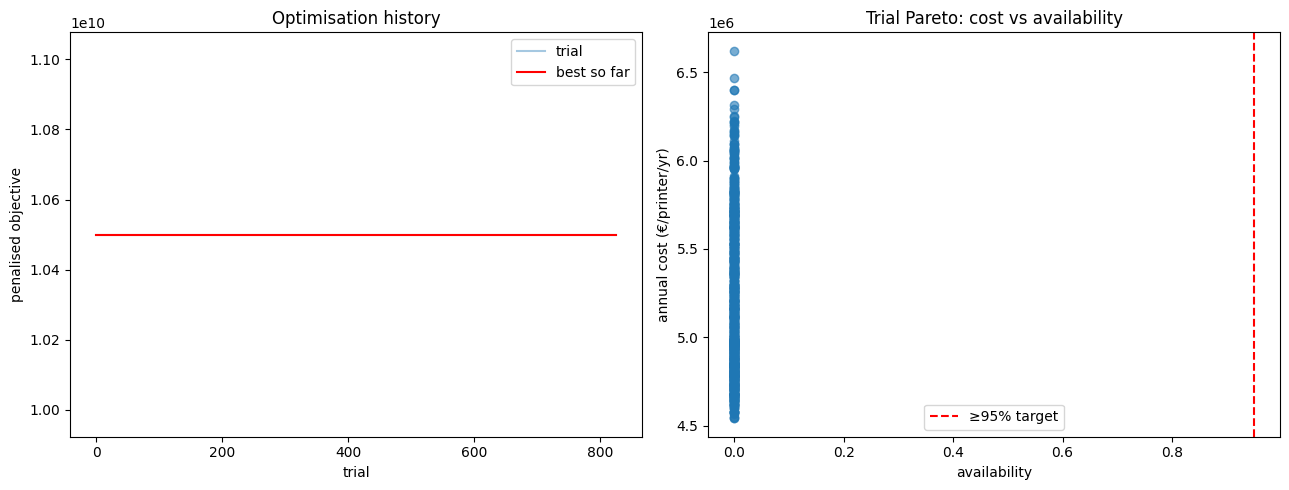

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
history = study.trials_dataframe().dropna(subset=['value'])
axes[0].plot(history['number'], history['value'], alpha=0.4, label='trial')
axes[0].plot(history['number'], history['value'].cummin(), color='red', label='best so far')
axes[0].set_xlabel('trial')
axes[0].set_ylabel('penalised objective')
axes[0].set_title('Optimisation history')
axes[0].legend()

study_df = study.trials_dataframe().dropna(subset=['user_attrs_annual_cost', 'user_attrs_availability'])
study_df = study_df.rename(columns={
    'user_attrs_annual_cost': 'annual_cost',
    'user_attrs_availability': 'availability',
})
plot_pareto_cost_availability(study_df, ax=axes[1])
axes[1].set_title('Trial Pareto: cost vs availability')
plt.tight_layout()
plt.show()

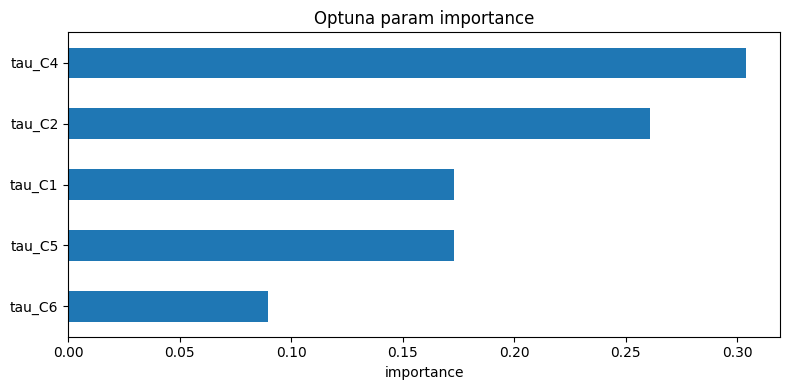

In [9]:
try:
    importance = optuna.importance.get_param_importances(study)
    pd.Series(importance).sort_values().plot(kind='barh', figsize=(8, 4), title='Optuna param importance')
    plt.xlabel('importance')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Importance unavailable:', exc)